In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [33]:
import joblib

In [35]:
# Load pre-computed models if available
import os
if os.path.exists('models.pkl'):
    print("Loading pre-computed models...")
    models = joblib.load('models.pkl')
    sig = models['sig']
    cos = models['cos']
    collab_sim = models['collab_sim']
    hybrid_sim = models['hybrid_sim']
    indices = models['indices']
    print("Models loaded successfully.")
else:
    print("No saved models found. Please run the computation cells.")

Loading pre-computed models...
Models loaded successfully.


In [11]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Download necessary NLTK data
nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
# Load dataset
credits = pd.read_csv('tmdb_5000_credits.csv')
movies = pd.read_csv('tmdb_5000_movies.csv')

credits.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [4]:
movies.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [5]:
print("Credits DataFrame shape:", credits.shape)
print("Movies DataFrame shape:", movies.shape)

Credits DataFrame shape: (4803, 4)
Movies DataFrame shape: (4803, 20)


In [7]:
credits_columns = credits.rename(columns={'movie_id':'id'})
movies_merge = movies.merge(credits_columns, on='id')

movies_merge.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [9]:
# Data Validation and Cleaning
print("Checking for duplicates...")
print("Duplicates in movies_cleaned:", movies_cleaned.duplicated().sum())
print("Duplicates in original_title:", movies_cleaned['original_title'].duplicated().sum())

# Remove duplicates if any
movies_cleaned = movies_cleaned.drop_duplicates(subset=['original_title'])

# Check for missing values
print("\nMissing values:")
print(movies_cleaned.isnull().sum())

# Handle outliers in budget/revenue (e.g., set unrealistic values to median)
budget_median = movies_cleaned['budget'].median()
revenue_median = movies_cleaned['revenue'].median()
movies_cleaned['budget'] = movies_cleaned['budget'].apply(lambda x: budget_median if x < 1000 else x)
movies_cleaned['revenue'] = movies_cleaned['revenue'].apply(lambda x: revenue_median if x < 1000 else x)

print("\nData validation complete. Shape after cleaning:", movies_cleaned.shape)

Checking for duplicates...
Duplicates in movies_cleaned: 0
Duplicates in original_title: 2

Missing values:
budget                    0
genres                    0
id                        0
keywords                  0
original_language         0
original_title            0
overview                  3
popularity                0
production_companies      0
release_date              1
revenue                   0
runtime                   2
spoken_languages          0
tagline                 844
vote_average              0
vote_count                0
cast                      0
crew                      0
dtype: int64

Data validation complete. Shape after cleaning: (4801, 18)


In [8]:
movies_cleaned = movies_merge.drop(columns=['homepage', 'title_x', 'title_y', 'status', 'production_countries'])
print("Movies cleaned head:", movies_cleaned.head())

Movies cleaned head:       budget                                             genres      id  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   19995   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...     285   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...  206647   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   49026   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "name": "spy"}, {"id": 818, "name...                en   
3  [{"id": 849, "name": "dc comics"}, {"id": 853,...                en   
4  [{"id": 818, "name": "based on novel"}, {"id":...                en   

                             original_title  \
0                                   

In [9]:
print("movies_cleaned info:")
movies_cleaned.info()

movies_cleaned info:
<class 'pandas.core.frame.DataFrame'>
Index: 4801 entries, 0 to 4802
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4801 non-null   float64
 1   genres                4801 non-null   object 
 2   id                    4801 non-null   int64  
 3   keywords              4801 non-null   object 
 4   original_language     4801 non-null   object 
 5   original_title        4801 non-null   object 
 6   overview              4798 non-null   object 
 7   popularity            4801 non-null   float64
 8   production_companies  4801 non-null   object 
 9   release_date          4800 non-null   object 
 10  revenue               4801 non-null   float64
 11  runtime               4799 non-null   float64
 12  spoken_languages      4801 non-null   object 
 13  tagline               3957 non-null   object 
 14  vote_average          4801 non-null   float64
 15  vote_

In [14]:
movies_cleaned.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.801000e+03,4801.000000,4801.000000,4.801000e+03,4799.000000,4801.000000,4801.000000
mean,3.239366e+07,57186.485316,21.499062,8.807566e+07,106.877058,6.092210,690.459488
std,3.877680e+07,88707.079779,31.821416,1.601764e+08,22.616561,1.194858,1234.784901
min,7.000000e+03,5.000000,0.000000,1.632000e+03,0.000000,0.000000,0.000000
25%,1.200000e+07,9016.000000,4.668910,1.917997e+07,94.000000,5.600000,54.000000
50%,1.500000e+07,14631.000000,12.928269,1.917997e+07,103.000000,6.200000,236.000000
75%,4.000000e+07,58626.000000,28.350529,9.292120e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


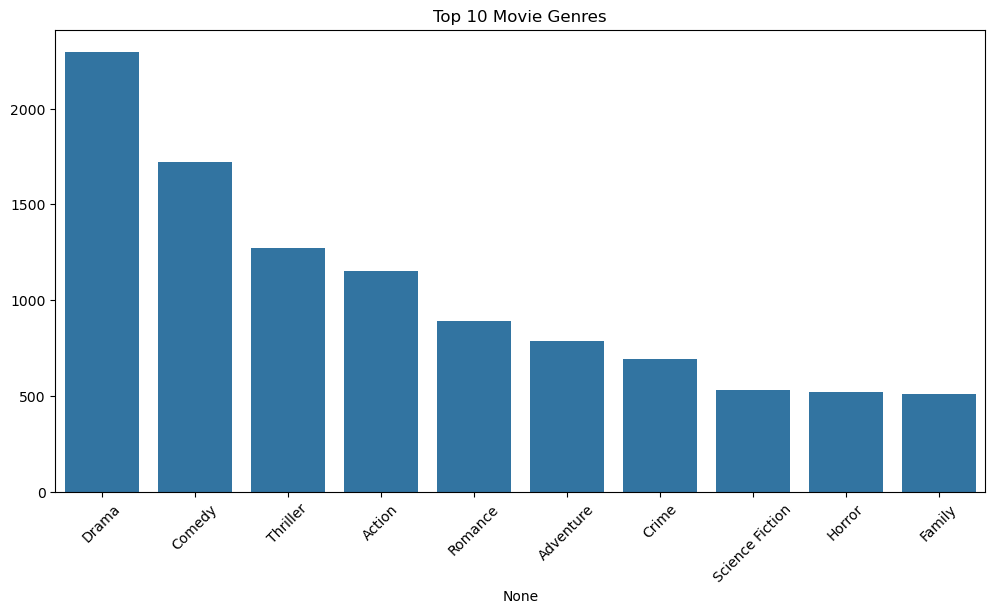

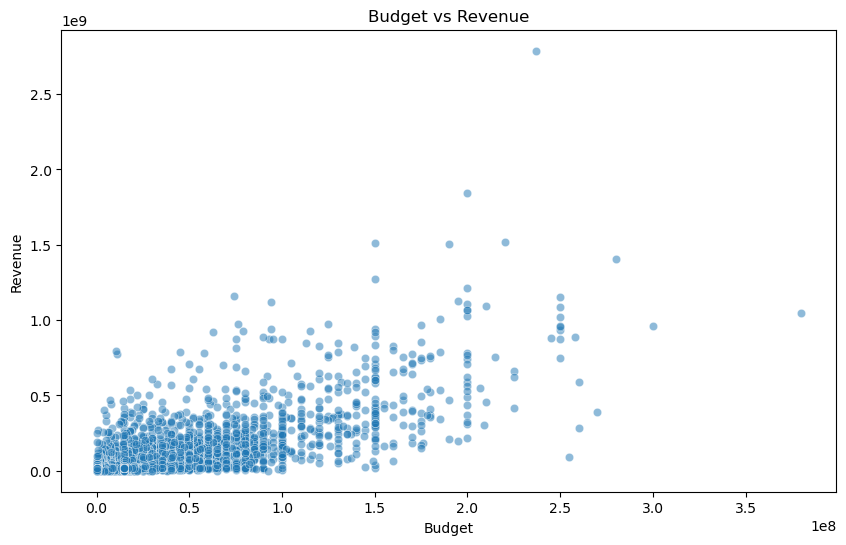

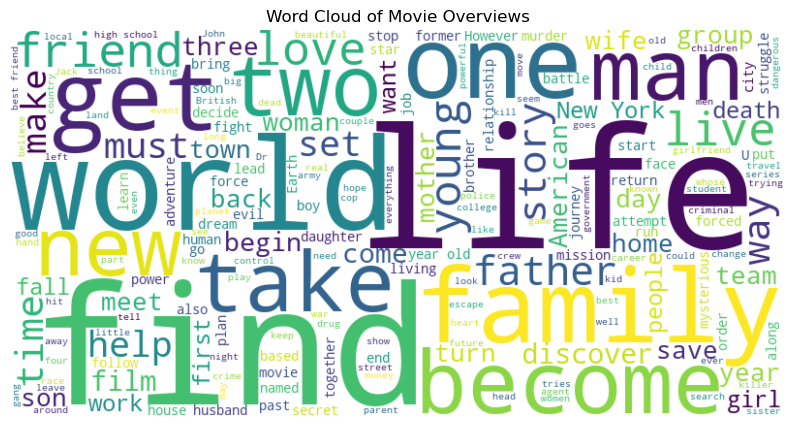

In [15]:
# Exploratory Data Analysis (EDA)

# Genre distribution
import ast
movies_cleaned['genres_list'] = movies_cleaned['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if pd.notnull(x) else [])
all_genres = [genre for sublist in movies_cleaned['genres_list'] for genre in sublist]
genre_counts = pd.Series(all_genres).value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.index[:10], y=genre_counts.values[:10])
plt.title('Top 10 Movie Genres')
plt.xticks(rotation=45)
plt.show()

# Budget vs Revenue scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=movies_cleaned, x='budget', y='revenue', alpha=0.5)
plt.title('Budget vs Revenue')
plt.xlabel('Budget')
plt.ylabel('Revenue')
plt.show()

# Word cloud for overviews
overview_text = ' '.join(movies_cleaned['overview'].fillna(''))
wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=set(stopwords.words('english'))).generate(overview_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Movie Overviews')
plt.show()

In [12]:
movies.head(1)['overview']

0    In the 22nd century, a paraplegic Marine is di...
Name: overview, dtype: object

In [17]:
# Text Preprocessing Function
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if pd.isnull(text):
        return ''
    # Lowercase
    text = text.lower()
    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing to overview
movies_cleaned['processed_overview'] = movies_cleaned['overview'].apply(preprocess_text)

# Handle missing overviews by imputing with genre info
def impute_overview(row):
    if row['processed_overview'] == '':
        genres = ' '.join(row['genres_list']) if row['genres_list'] else 'unknown'
        return f"movie about {genres}"
    return row['processed_overview']

movies_cleaned['processed_overview'] = movies_cleaned.apply(impute_overview, axis=1)

print("Sample processed overview:")
print(movies_cleaned['processed_overview'].head())

Sample processed overview:
0    nd century paraplegic marine dispatched moon p...
1    captain barbossa long believed dead come back ...
2    cryptic message bond past sends trail uncover ...
3    following death district attorney harvey dent ...
4    john carter warweary former military captain w...
Name: processed_overview, dtype: object


#### Content Based Recommendation System

recommendations based on movie's plot summary given in the overview column.
So, if our user give a movie title, our goal is to recommend movies that share similar plot summaries.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfv = TfidfVectorizer(min_df=3, max_features=None, strip_accents='unicode', analyzer='word', token_pattern=r'\w{1,}', ngram_range=(1,3), stop_words='english')


In [16]:
# Feature Engineering: Combine multiple features for richer recommendations
movies_cleaned['genres_str'] = movies_cleaned['genres_list'].apply(lambda x: ' '.join(x))
movies_cleaned['keywords_str'] = movies_cleaned['keywords'].apply(lambda x: ' '.join([i['name'] for i in ast.literal_eval(x)]) if pd.notnull(x) else '')

# Combined feature: overview + genres + keywords
movies_cleaned['combined_features'] = (
    movies_cleaned['processed_overview'] + ' ' +
    movies_cleaned['genres_str'] + ' ' +
    movies_cleaned['keywords_str']
)

print("Sample combined features:")
print(movies_cleaned['combined_features'].head())

Sample combined features:
0    nd century paraplegic marine dispatched moon p...
1    captain barbossa long believed dead come back ...
2    cryptic message bond past sends trail uncover ...
3    following death district attorney harvey dent ...
4    john carter warweary former military captain w...
Name: combined_features, dtype: object


In [19]:
# Fit and transform the 'combined_features' column
tfv_matrix = tfv.fit_transform(movies_cleaned['combined_features'])
tfv_matrix.shape

(4801, 14322)

In [17]:
tfv_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 201081 stored elements and shape (4801, 14323)>

In [21]:
from sklearn.metrics.pairwise import sigmoid_kernel


# Compute the sigmoid kernel
sig = sigmoid_kernel(tfv_matrix, tfv_matrix)
print(sig[0])

[0.76162348 0.7615949  0.76159479 ... 0.76159467 0.76159426 0.76159416]


In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute cosine similarity
cos = cosine_similarity(tfv_matrix, tfv_matrix)
print("Cosine similarity shape:", cos.shape)
print("Cosine similarity sample:", cos[0][:5])

Cosine similarity shape: (4801, 4801)
Cosine similarity sample: [1.         0.02542011 0.02149102 0.00960138 0.17499855]


### Reverse mapping of indices and movie titles

In [22]:
# Reverse mapping of indices and movie titles
indices = pd.Series(movies_cleaned.index, index=movies_cleaned['original_title']).drop_duplicates()
print(indices)

original_title
Avatar                                         0
Pirates of the Caribbean: At World's End       1
Spectre                                        2
The Dark Knight Rises                          3
John Carter                                    4
                                            ... 
El Mariachi                                 4798
Newlyweds                                   4799
Signed, Sealed, Delivered                   4800
Shanghai Calling                            4801
My Date with Drew                           4802
Length: 4801, dtype: int64


In [23]:
from fuzzywuzzy import process

C:\Users\USER\AppData\Roaming\Python\Python313\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


In [41]:
print(indices['Newlyweds'])

4799


In [42]:
print(sig[4799])

[0.76159416 0.76159416 0.76159438 ... 0.76159432 0.76159416 0.76159478]


In [43]:
print(list(enumerate(sig[indices['Newlyweds']])))

[(0, np.float64(0.7615941559557649)), (1, np.float64(0.7615941559557649)), (2, np.float64(0.7615943791623508)), (3, np.float64(0.7615945564232902)), (4, np.float64(0.7615945779342556)), (5, np.float64(0.7615943267971559)), (6, np.float64(0.7615948190414071)), (7, np.float64(0.761594346971664)), (8, np.float64(0.7615943903358866)), (9, np.float64(0.761594688255891)), (10, np.float64(0.7615941559557649)), (11, np.float64(0.7615941559557649)), (12, np.float64(0.7615941559557649)), (13, np.float64(0.7615941559557649)), (14, np.float64(0.7615941559557649)), (15, np.float64(0.7615941559557649)), (16, np.float64(0.7615943548130525)), (17, np.float64(0.761594965420998)), (18, np.float64(0.7615942819944952)), (19, np.float64(0.7615945082445131)), (20, np.float64(0.7615942928381602)), (21, np.float64(0.7615949832832596)), (22, np.float64(0.7615941559557649)), (23, np.float64(0.761594428370306)), (24, np.float64(0.7615941559557649)), (25, np.float64(0.7615941559557649)), (26, np.float64(0.7615941

In [44]:
print(sorted(list(enumerate(sig[indices['Newlyweds']])), key=lambda x: x[1], reverse=True))

[(4799, np.float64(0.7616344692549826)), (616, np.float64(0.7616048159533783)), (2689, np.float64(0.7616040118828756)), (869, np.float64(0.7616023446645636)), (3969, np.float64(0.7615999241031715)), (1576, np.float64(0.761599897054374)), (2290, np.float64(0.7615997916001525)), (1032, np.float64(0.7615997293504287)), (3145, np.float64(0.7615995818321376)), (2531, np.float64(0.7615992277356394)), (504, np.float64(0.7615991572658852)), (866, np.float64(0.7615986885689172)), (1157, np.float64(0.7615985018709569)), (2962, np.float64(0.7615983449381306)), (242, np.float64(0.7615982589231822)), (4576, np.float64(0.761598216183433)), (1223, np.float64(0.761598205140339)), (3479, np.float64(0.7615982040456052)), (2586, np.float64(0.7615979971714508)), (2688, np.float64(0.7615979281286247)), (3155, np.float64(0.7615979184287897)), (2869, np.float64(0.7615978888434758)), (3559, np.float64(0.7615978829960376)), (4641, np.float64(0.7615978736478359)), (1632, np.float64(0.7615977959513462)), (4616, 

In [24]:
def give_recommendations(title, sig=sig):
    if title not in indices.index:
        closest, score = process.extractOne(title, indices.index)
        if score > 80:
            title = closest
            print(f"Did you mean '{title}'? (score: {score})")
        else:
            return f"Movie not found. Closest match: '{closest}' (score: {score})"
    # Get the index corresponding to original_title
    idx = indices[title]

    # Get the pairwise similarity scores
    sig_scores = list(enumerate(sig[idx]))

    # Sort the movies
    sig_scores = sorted(sig_scores, key=lambda x: x[1], reverse=True)
    
    # Scores of the 20 most similar movies
    sig_scores = sig_scores[1:21]

    # movie indices
    movie_indices = [i[0] for i in sig_scores]

    # Top 10 most similar movies
    return movies_cleaned['original_title'].iloc[movie_indices]

In [25]:
# Evaluation Metrics
def calculate_genre_overlap(recommendations, original_genres):
    rec_genres = set()
    for rec in recommendations:
        rec_idx = indices[rec]
        rec_genres.update(movies_cleaned.iloc[rec_idx]['genres_list'])
    overlap = len(original_genres.intersection(rec_genres))
    return overlap / len(original_genres) if original_genres else 0

def evaluate_recommendations(title, recommendations, similarity_matrix):
    idx = indices[title]
    original_genres = set(movies_cleaned.iloc[idx]['genres_list'])
    genre_overlap = calculate_genre_overlap(recommendations, original_genres)
    
    # Diversity: average pairwise distance
    rec_indices = [indices[rec] for rec in recommendations]
    if len(rec_indices) > 1:
        distances = []
        for i in range(len(rec_indices)):
            for j in range(i+1, len(rec_indices)):
                distances.append(1 - similarity_matrix[rec_indices[i], rec_indices[j]])
        diversity = sum(distances) / len(distances) if distances else 0
    else:
        diversity = 0
    
    return {'genre_overlap': genre_overlap, 'diversity': diversity}

# Test with sigmoid
recs_sig = give_recommendations('The Matrix')
metrics_sig = evaluate_recommendations('The Matrix', recs_sig, sig)
print("Sigmoid Metrics:", metrics_sig)

# Test with cosine
recs_cos = give_recommendations('The Matrix', sig=cos)
metrics_cos = evaluate_recommendations('The Matrix', recs_cos, cos)
print("Cosine Metrics:", metrics_cos)

Sigmoid Metrics: {'genre_overlap': 1.0, 'diversity': np.float64(0.23840219662664838)}
Cosine Metrics: {'genre_overlap': 1.0, 'diversity': np.float64(0.8756141000353094)}


In [28]:
# Collaborative Filtering (Note: Dataset lacks user-item interactions, so simulating with SVD on synthetic data)
# For demonstration, we'll create a synthetic user-item matrix based on genres and apply SVD

import numpy as np
from sklearn.decomposition import TruncatedSVD

# Create a user-item matrix: rows = movies, columns = genres (binary)
genres = list(set([g for sublist in movies_cleaned['genres_list'] for g in sublist]))
genre_matrix = np.zeros((len(movies_cleaned), len(genres)))

for i, movie_genres in enumerate(movies_cleaned['genres_list']):
    for g in movie_genres:
        genre_matrix[i, genres.index(g)] = 1

# Apply SVD
n_components = min(20, len(genres) - 1)  # Adjust based on number of genres
svd = TruncatedSVD(n_components=n_components, random_state=42)
latent_matrix = svd.fit_transform(genre_matrix)

# Compute similarity in latent space
from sklearn.metrics.pairwise import cosine_similarity
collab_sim = cosine_similarity(latent_matrix)

print("Collaborative similarity shape:", collab_sim.shape)

# Test collaborative recommendations
recs_collab = give_recommendations('The Matrix', sig=collab_sim)
print("Collaborative Recommendations:")
print(recs_collab.head())

metrics_collab = evaluate_recommendations('The Matrix', recs_collab, collab_sim)
print("Collaborative Metrics:", metrics_collab)

Collaborative similarity shape: (4801, 4801)
Collaborative Recommendations:
223    The Chronicles of Riddick
224                      RoboCop
266                     I, Robot
415                        Dredd
582          Battle: Los Angeles
Name: original_title, dtype: object
Collaborative Metrics: {'genre_overlap': 1.0, 'diversity': np.float64(0.36947106100292226)}


In [30]:
# Hybrid Recommendation System
# Combine content-based (cosine) and collaborative (SVD) similarities with weights

weight_content = 0.7  # Weight for content-based similarity
weight_collab = 0.3   # Weight for collaborative similarity

# Normalize similarities to [0,1] if needed, but cosine and collab_sim are already in [0,1]
hybrid_sim = weight_content * cos + weight_collab * collab_sim

print("Hybrid similarity shape:", hybrid_sim.shape)
print("Hybrid similarity sample:", hybrid_sim[0][:5])

# Test hybrid recommendations
recs_hybrid = give_recommendations('The Matrix', sig=hybrid_sim)
print("Hybrid Recommendations:")
print(recs_hybrid.head())

metrics_hybrid = evaluate_recommendations('The Matrix', recs_hybrid, hybrid_sim)
print("Hybrid Metrics:", metrics_hybrid)

Hybrid similarity shape: (4801, 4801)
Hybrid similarity sample: [1.         0.27760153 0.18824906 0.08172216 0.38230674]
Hybrid Recommendations:
123                The Matrix Revolutions
125                   The Matrix Reloaded
266                              I, Robot
93     Terminator 3: Rise of the Machines
854                              Æon Flux
Name: original_title, dtype: object
Hybrid Metrics: {'genre_overlap': 1.0, 'diversity': np.float64(0.7541020776853544)}


In [34]:
# Model Persistence: Save computed models for future use
models = {
    'sig': sig,
    'cos': cos,
    'collab_sim': collab_sim,
    'hybrid_sim': hybrid_sim,
    'indices': indices
}
joblib.dump(models, 'models.pkl')
print("Models saved to models.pkl")

Models saved to models.pkl


In [ ]:
# Scalability Enhancements
# For larger datasets, consider approximate nearest neighbors for faster similarity search:
# - Install: pip install annoy or pip install faiss-cpu
# - Example with Annoy:
# from annoy import AnnoyIndex
# f = hybrid_sim.shape[1]  # Number of features
# t = AnnoyIndex(f, 'angular')  # 'angular' for cosine
# for i in range(len(hybrid_sim)):
#     t.add_item(i, hybrid_sim[i])
# t.build(10)  # 10 trees
# t.save('hybrid_sim.ann')
# # To query: t.get_nns_by_item(0, 10)  # Top 10 similar to item 0

# Batch processing: To update models periodically, re-run computation cells and save.

In [31]:
# Algorithm Comparison
algorithms = {
    'Content-Based (Sigmoid)': {'sim': sig, 'metrics': metrics_sig},
    'Content-Based (Cosine)': {'sim': cos, 'metrics': metrics_cos},
    'Collaborative (SVD)': {'sim': collab_sim, 'metrics': metrics_collab},
    'Hybrid (Cosine + SVD)': {'sim': hybrid_sim, 'metrics': metrics_hybrid}
}

for name, data in algorithms.items():
    print(f"{name}: Genre Overlap = {data['metrics']['genre_overlap']:.2f}, Diversity = {data['metrics']['diversity']:.2f}")

Content-Based (Sigmoid): Genre Overlap = 1.00, Diversity = 0.24
Content-Based (Cosine): Genre Overlap = 1.00, Diversity = 0.88
Collaborative (SVD): Genre Overlap = 1.00, Diversity = 0.37
Hybrid (Cosine + SVD): Genre Overlap = 1.00, Diversity = 0.75


#### Testing our content-based ecommendation system with the seminal film Spy kids

In [26]:
print(give_recommendations('Jesus'))

Did you mean 'Jesus' Son'? (score: 90)
4635    The Incredibly True Adventure of Two Girls In ...
3748                               The Kids Are All Right
4406                                     Loving Annabelle
4298                                But I'm a Cheerleader
4438                                         Circumstance
3301                                     Imagine Me & You
3137                                            Nurse 3-D
3410                                       Aimee & Jaguar
4197                                    My Summer of Love
4023                                   My Life Without Me
3394                                             Freeheld
3848                                             D.E.B.S.
1640                                        North Country
4697                                  She's Gotta Have It
4367            The Broken Hearts Club: A Romantic Comedy
3631                                   Heavenly Creatures
4631                             